# Applied Machine Learning

## Assignment1 - ShunFai Lee

### Question1:

- a 
    - Training data set is a subset of all the data points of a complete sample of data used for model training.
    - Validation dataset is another non-overlapping subset that is for evaluation and tuning the model.
    - Testing dataset is another non-overlapping subset used as a benchmark for real world performance.
- b 
    - Ground truth is the stored correct value of a data point outcome. 
    - Label is also the ground truth, but a translated mapping, with actual names, instead of numbers/integers
- c 
    - Pre-processing is the process of reshaping data become feeding into learning model. 
    - Feature is a column in a data set, and corresponds to an attribute value of a data point, and is the input to the machine learning model.
- d
    - decision surface is a decision boundary in 3-dimensional data space that partitioned the class of data points
- e 
    - model validation is the process of evaluating the model performance with validation dataset for tuning the model.
    - accuracy is the proportion of correctly predicted or classified data points
    - cross-validation is a form of validation, that divide training set into many portions, and each of the portions are used on training and validated with the remaining portions.
- f
    - parameters are the weighting on attributes of data learnt during the training data
    - hyperparameters are some parameters on the training model that is not learnt from training, such as the learning rate, number of trees in random forest.
    - overfit means that the model captures the patterns in the training data well but fails to generalize well to unseen data (text book chapter 3)
- g
    - re-evaluation is the process of conducting testing again after changes are made on model to evaluate the new updated performance

In [21]:
#import all needed libraries
from sklearn import datasets, metrics, svm
from sklearn.model_selection import train_test_split
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns; sns.set_theme(style="ticks", color_codes=True) 
import pandas as pd

### Question2:

#### The Iris dataset

In [22]:
#load iris data set
iris = datasets.load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [23]:
#print data length
print(f"Number of data points:{len(iris.data)}")
#print features name and type
print(f"Number of features: {len(iris.feature_names)}, data types: {iris.data.dtype}")
#print target number and names
print(f"Number of target/categories is {len(iris.target_names)}, names of target are: {iris.target_names} ")
#print means
print(f"mean of feature 0: {np.mean(iris.data[:,0])}, mean of feature 1: {np.mean(iris.data[:,1])}")

Number of data points:150
Number of features: 4, data types: float64
Number of target/categories is 3, names of target are: ['setosa' 'versicolor' 'virginica'] 
mean of feature 0: 5.843333333333334, mean of feature 1: 3.0573333333333337


### Question2 Answer:

- a
    - Total number of data points is 150
- b
    - Total number of features is 4 and data type is numerical
- c
    - Number of categories is 3 and their names are ['setosa' 'versicolor' 'virginica'] 
- d
    - Mean of feature 0 is 5.84 and mean of feature 1: 3.0573

### Question3:

#### The Wine dataset

In [24]:
#load wine data set
wine = datasets.load_wine()
wine

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
         1.065e+03],
        [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
         1.050e+03],
        [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
         1.185e+03],
        ...,
        [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
         8.350e+02],
        [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
         8.400e+02],
        [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
         5.600e+02]], shape=(178, 13)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [25]:
#print data length
print(f"Number of data points:{len(wine.data)}")
#print features name and type
print(f"Number of features: {len(wine.feature_names)}, data types: {wine.data.dtype}")
#print target number and names
print(f"Number of target/categories is {len(wine.target_names)}, names of target are: {wine.target_names} ")
#print means
print(f"mean of feature 0: {np.mean(wine.data[:,0])}, mean of feature 1: {np.mean(wine.data[:,1])}")

Number of data points:178
Number of features: 13, data types: float64
Number of target/categories is 3, names of target are: ['class_0' 'class_1' 'class_2'] 
mean of feature 0: 13.00061797752809, mean of feature 1: 2.3363483146067416


### Question3 Answer:

- a
    - Total number of data points is 178
- b
    - Total number of features is 13 and data type is numerical
- c
    - Number of categories is 3 and their names are ['class_0' 'class_1' 'class_2']
- d
    - Mean of feature 0 is 13.00 and mean of feature 1: 2.34

### Question4:

#### Part 1: The Iris dataset

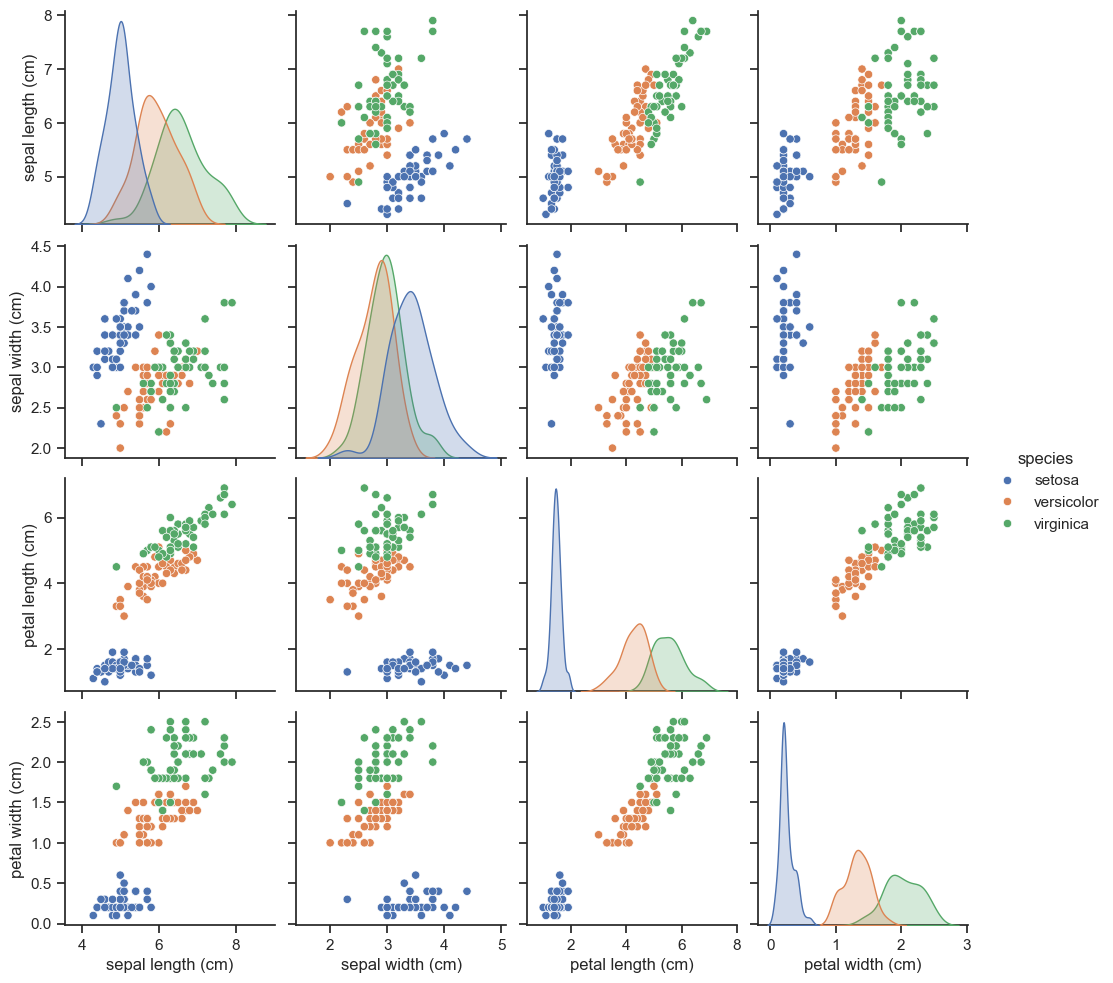

In [26]:
#use loaded dataset from question 2 and plot the data pairs
iris_df = pd.DataFrame(data= np.c_[iris.data, [iris.target_names[v] for v in iris.target]], 
                        columns= iris.feature_names + ['species']) 
cols = iris_df.columns.drop('species') 
iris_df[cols] = iris_df[cols].apply(pd.to_numeric) 
g = sns.pairplot(iris_df, hue='species') 

### Question4 Answer :
#### Part 1: iris data set

By looking at the plots, features petal length and petal width shows the strongest class separation for machine learning. It is because the distribution for each species show a smaller class variance, as compared the other two features.<br>
Also, the overlap area between class are smaller than in the other two features, which means we will observe different species point are further apart from each other, corresponing to a larger global variance between classes and is benefitial for a faster training process.

### Question4:

#### Part 2: The Wine dataset

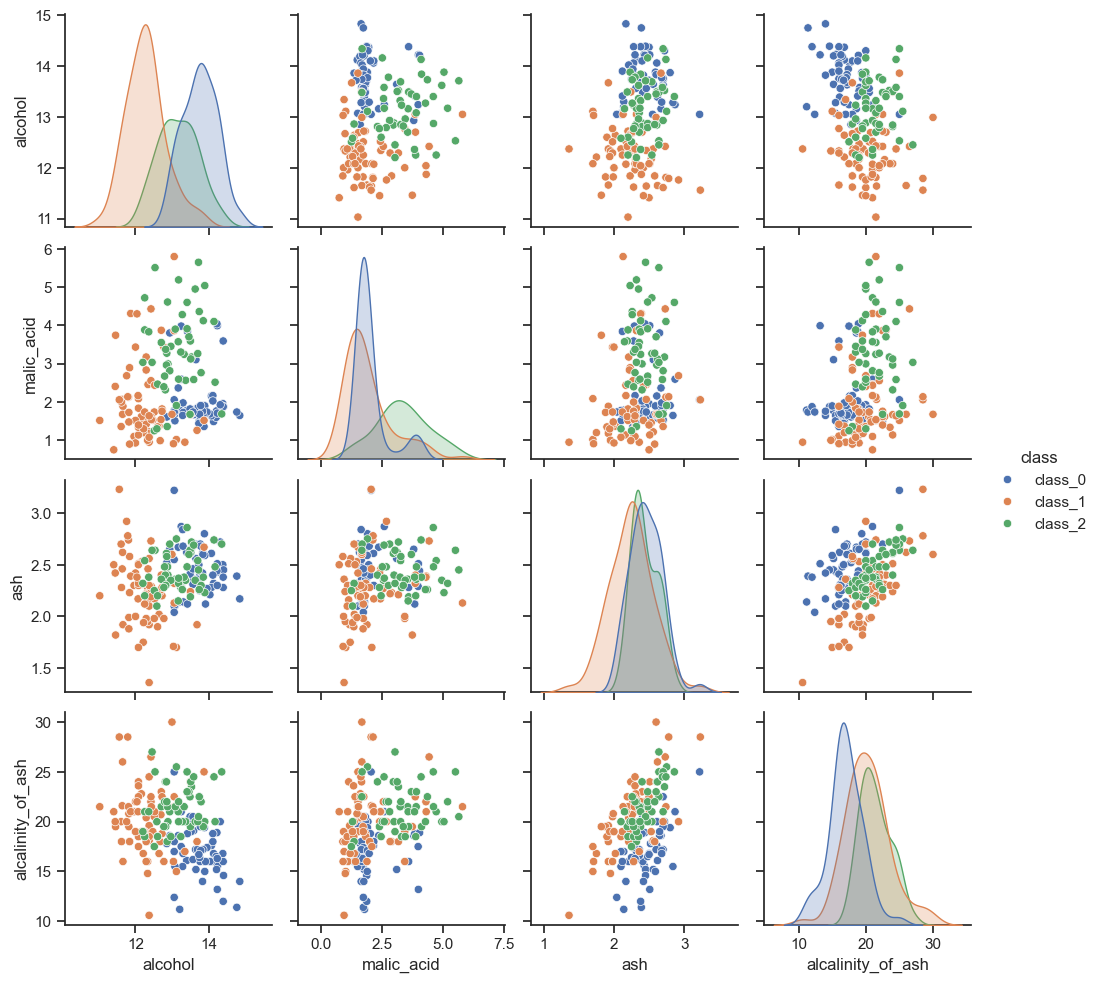

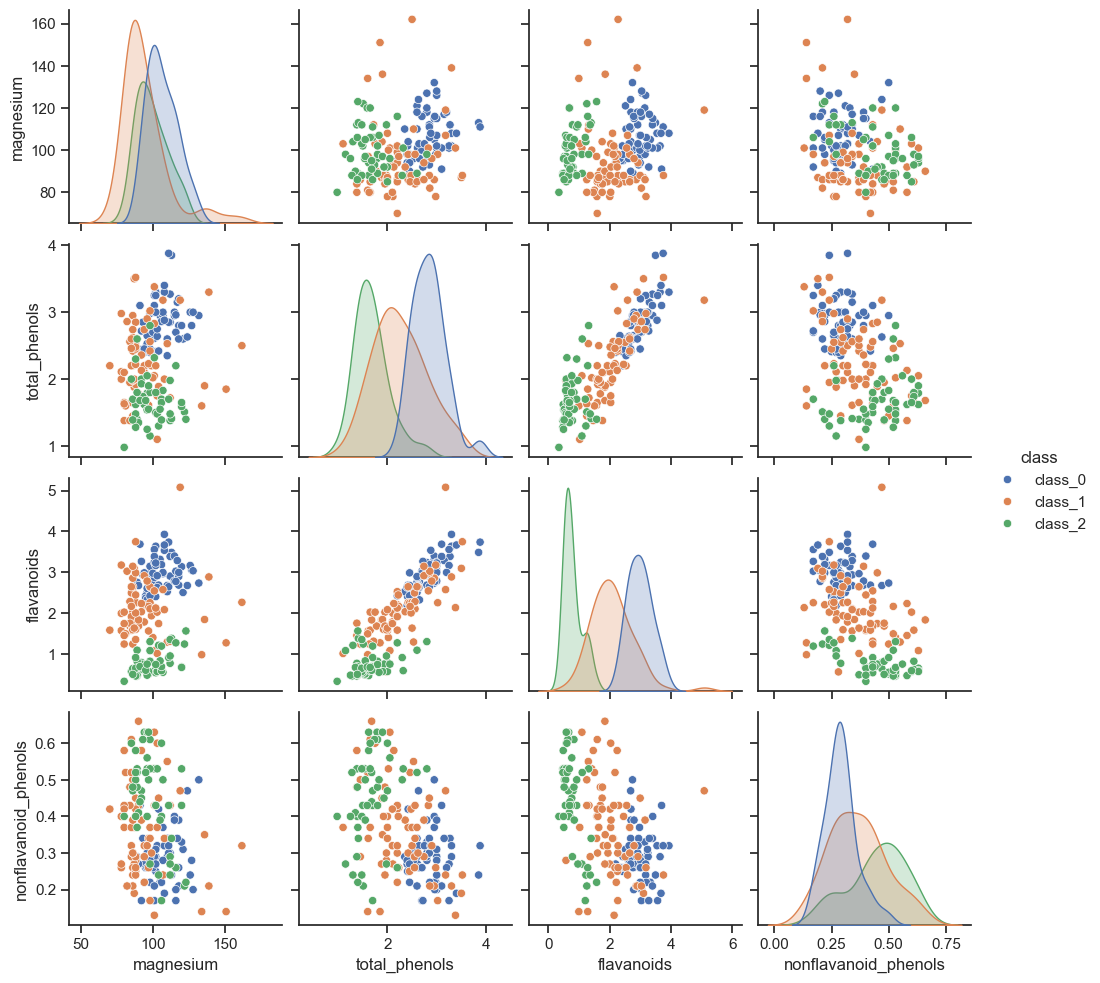

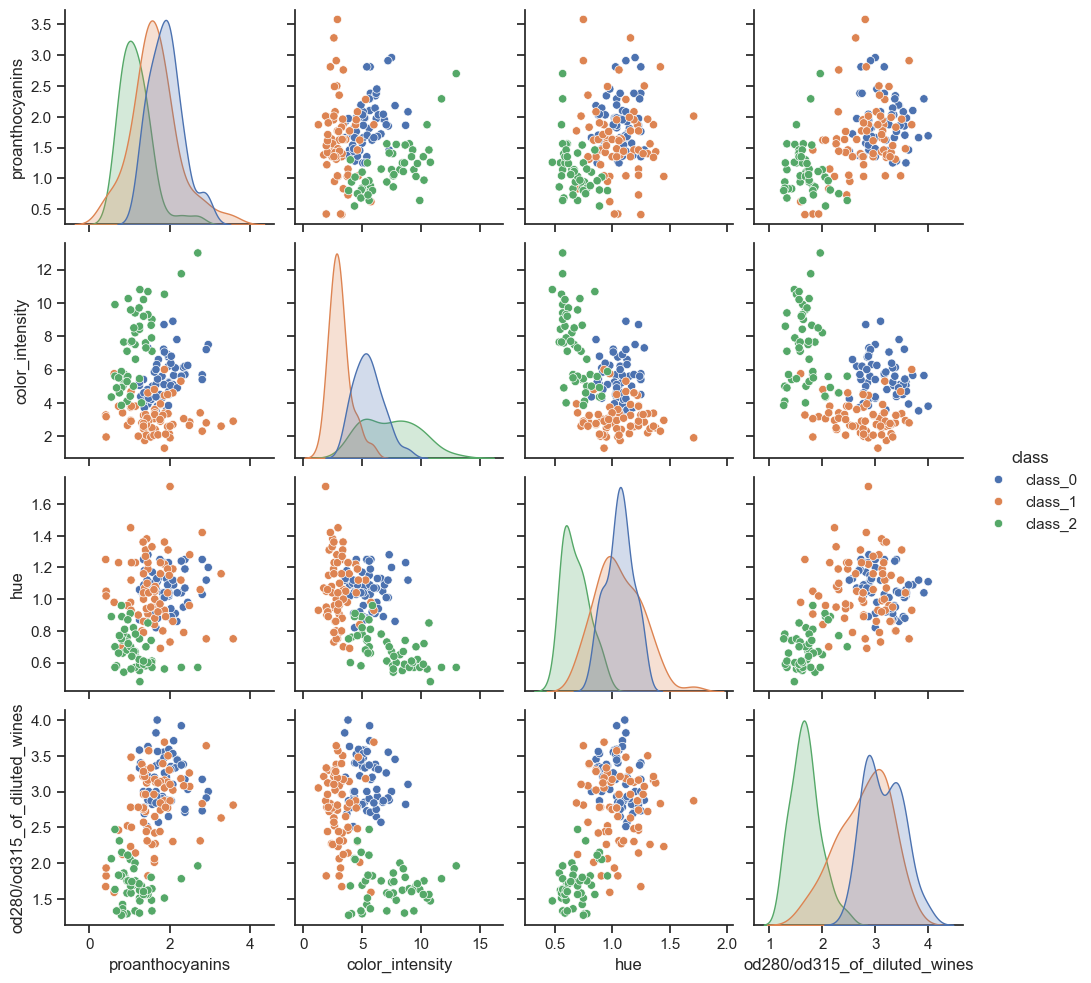

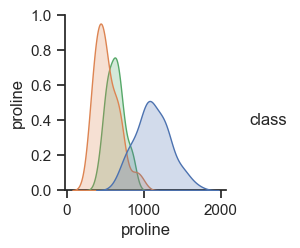

In [27]:
#use loaded dataset from question 3 and plot the data pairs
wine_df = pd.DataFrame(data= np.c_[wine.data, [wine.target_names[v] for v in wine.target]], 
                        columns= wine.feature_names + ['class']) 
cols = wine_df.columns.drop('class') 
wine_df[cols] = wine_df[cols].apply(pd.to_numeric) 
#look at the pair plot 4 at a time
g = sns.pairplot(wine_df.iloc[:,np.r_[0:4,-1]], hue='class')
g = sns.pairplot(wine_df.iloc[:,np.r_[4:8,-1]], hue='class')
g = sns.pairplot(wine_df.iloc[:,np.r_[8:12,-1]], hue='class')
g = sns.pairplot(wine_df.iloc[:,np.r_[12:13,-1]], hue='class')


### Question4 Answer 
#### Part 2: wine data set

By looking at the plots, feature favanoids shows the strongest class separation for machine learning. It is because the distribution for each class are more distinct with smaller class variance, as compared the other two features.<br>
Also, the overlap area between classes are amongst the smallest than in the other features.

### Question5:

- a 
    - I would use features petal length and petal width because the data points are clustered quite well, with very distinct boundaries.

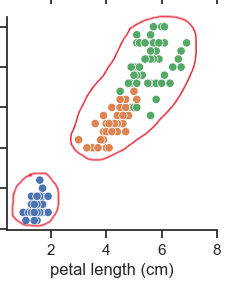
- b 
    - In terms of clustering, the data pair plots of petal length and petal width shows two distinct cluster very well, but not three, even though the labels show that the bigger cluster consist of two different classes, but without another evaluation on data points of that particular cluster against other features, it is not safe to separate that particular big cluster into two.
- c
    - As shown on the above captured of plot of petal width(y-axis) vs petel length(x-axis), there are two distinct cluster observed, 1 small and 1 bigger cluster. In terms of clustering, there is not the 3rd and 4th cluster.
- d
    - In this particular set, the clustering is related to classes, but they do not aligned perfectly. The small distinct in lower left corner represent the setosa class very well. However, the bigger cluster consist of two classes. So a data point falling inside that cluster have chance of being either versicolor or virginica.

### Question6:

#### Naive Bayes and decision trees on The Iris dataset

## Classification

To apply a classifier on this data, we need to flatten the images, turning
each 2-D array of grayscale values from shape ``(8, 8)`` into shape
``(64,)``. Subsequently, the entire dataset will be of shape
``(n_samples, n_features)``, where ``n_samples`` is the number of images and
``n_features`` is the total number of pixels in each image.

We can then split the data into train and test subsets and fit a support
vector classifier on the train samples. The fitted classifier can
subsequently be used to predict the value of the digit for the samples
in the test subset.



In [29]:
# flatten the images
n_samples = len(digits.images)
data = digits.images.reshape((n_samples, -1))

# Create a classifier: a support vector classifier
clf = svm.SVC(gamma=0.001)

# Split data into 50% train and 50% test subsets
X_train, X_test, y_train, y_test = train_test_split(
    data, digits.target, test_size=0.5, shuffle=False
)

# Learn the digits on the train subset
clf.fit(X_train, y_train)

# Predict the value of the digit on the test subset
predicted = clf.predict(X_test)

Below we visualize the first 4 test samples and show their predicted
digit value in the title.



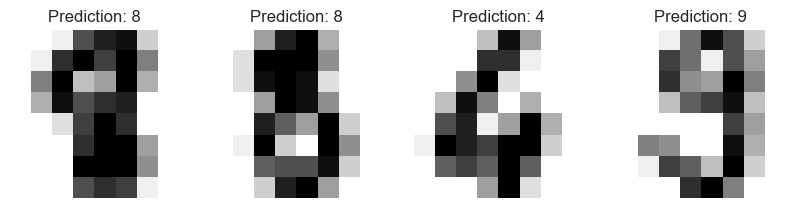

In [30]:
_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
for ax, image, prediction in zip(axes, X_test, predicted):
    ax.set_axis_off()
    image = image.reshape(8, 8)
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title(f"Prediction: {prediction}")

:func:`~sklearn.metrics.classification_report` builds a text report showing
the main classification metrics.



In [31]:
print(
    f"Classification report for classifier {clf}:\n"
    f"{metrics.classification_report(y_test, predicted)}\n"
)

Classification report for classifier SVC(gamma=0.001):
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        88
           1       0.99      0.97      0.98        91
           2       0.99      0.99      0.99        86
           3       0.98      0.87      0.92        91
           4       0.99      0.96      0.97        92
           5       0.95      0.97      0.96        91
           6       0.99      0.99      0.99        91
           7       0.96      0.99      0.97        89
           8       0.94      1.00      0.97        88
           9       0.93      0.98      0.95        92

    accuracy                           0.97       899
   macro avg       0.97      0.97      0.97       899
weighted avg       0.97      0.97      0.97       899




We can also plot a `confusion matrix <confusion_matrix>` of the
true digit values and the predicted digit values.



Confusion matrix:
[[87  0  0  0  1  0  0  0  0  0]
 [ 0 88  1  0  0  0  0  0  1  1]
 [ 0  0 85  1  0  0  0  0  0  0]
 [ 0  0  0 79  0  3  0  4  5  0]
 [ 0  0  0  0 88  0  0  0  0  4]
 [ 0  0  0  0  0 88  1  0  0  2]
 [ 0  1  0  0  0  0 90  0  0  0]
 [ 0  0  0  0  0  1  0 88  0  0]
 [ 0  0  0  0  0  0  0  0 88  0]
 [ 0  0  0  1  0  1  0  0  0 90]]


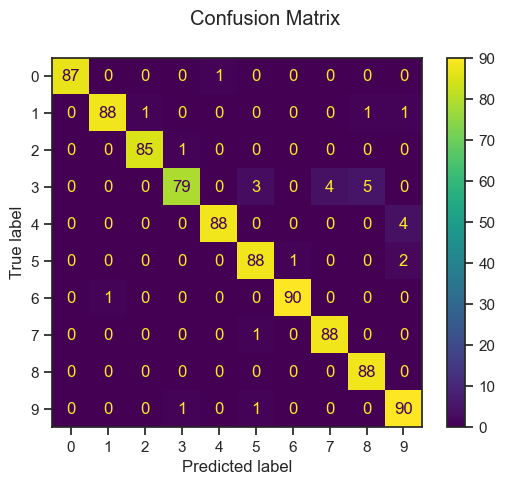

In [32]:
disp = metrics.ConfusionMatrixDisplay.from_predictions(y_test, predicted)
disp.figure_.suptitle("Confusion Matrix")
print(f"Confusion matrix:\n{disp.confusion_matrix}")

plt.show()

If the results from evaluating a classifier are stored in the form of a
`confusion matrix <confusion_matrix>` and not in terms of `y_true` and
`y_pred`, one can still build a :func:`~sklearn.metrics.classification_report`
as follows:



In [33]:
# The ground truth and predicted lists
y_true = []
y_pred = []
cm = disp.confusion_matrix

# For each cell in the confusion matrix, add the corresponding ground truths
# and predictions to the lists
for gt in range(len(cm)):
    for pred in range(len(cm)):
        y_true += [gt] * cm[gt][pred]
        y_pred += [pred] * cm[gt][pred]

print(
    "Classification report rebuilt from confusion matrix:\n"
    f"{metrics.classification_report(y_true, y_pred)}\n"
)

Classification report rebuilt from confusion matrix:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        88
           1       0.99      0.97      0.98        91
           2       0.99      0.99      0.99        86
           3       0.98      0.87      0.92        91
           4       0.99      0.96      0.97        92
           5       0.95      0.97      0.96        91
           6       0.99      0.99      0.99        91
           7       0.96      0.99      0.97        89
           8       0.94      1.00      0.97        88
           9       0.93      0.98      0.95        92

    accuracy                           0.97       899
   macro avg       0.97      0.97      0.97       899
weighted avg       0.97      0.97      0.97       899


